In [1]:
import pandas as pd
import requests

In [2]:
# Obter dados de câmbio do BCB
url = "https://api.bcb.gov.br/dados/serie/bcdata.sgs.10813/dados"
params = {
    "formato": "json",
    "dataInicial": "01/01/2023",
    "dataFinal": "31/12/2024"
}

response = requests.get(url, params=params)
cambio = pd.DataFrame(response.json())

pd.concat([cambio.head(5), cambio.tail(5)])

,data,valor
0,02/01/2023,5.3430
1,03/01/2023,5.3753
2,04/01/2023,5.4453
3,05/01/2023,5.4020
4,06/01/2023,5.2849
497,24/12/2024,6.1527
498,26/12/2024,6.1650
499,27/12/2024,6.1985
500,30/12/2024,6.1917
501,31/12/2024,6.1917


In [3]:
# Tratamento dos dados do BCB
cambio["data"] = pd.to_datetime(cambio["data"], dayfirst=True)
cambio["usd_brl"] = cambio["valor"].astype(float)

# Preencher datas faltantes 
cambio = cambio.set_index('data')
calendario_completo = pd.date_range("2023-01-01", "2024-12-31", freq="D")
cambio = cambio.reindex(calendario_completo)
cambio['usd_brl'] = cambio['usd_brl'].ffill().bfill() 
cambio = cambio.reset_index().rename(columns={'index': 'data'})

pd.concat([cambio.head(5), cambio.tail(5)])

,data,valor,usd_brl
0,2023-01-01,NaN,5.3430
1,2023-01-02,5.3430,5.3430
2,2023-01-03,5.3753,5.3753
3,2023-01-04,5.4453,5.4453
4,2023-01-05,5.4020,5.4020
726,2024-12-27,6.1985,6.1985
727,2024-12-28,NaN,6.1985
728,2024-12-29,NaN,6.1985
729,2024-12-30,6.1917,6.1917
730,2024-12-31,6.1917,6.1917


In [14]:
# Carregar Vendas e Custos
vendas = pd.read_csv('../datasets_tratados/vendas_normalizadas.csv')
custos = pd.read_csv('../datasets_tratados/custos_importacao.csv')

In [ ]:
# Cruzamento de Dados (Merge)
# Primeiro: Venda + Câmbio do dia
# Usamos left_on para a coluna de vendas e right_on para a coluna de câmbio
vendas = pd.merge(
    vendas, 
    cambio[['data', 'usd_brl']], 
    left_on='sale_date', 
    right_on='data',
    how='left')

# Segundo: Venda + Custo vigente (merge_asof)
vendas = vendas.sort_values("sale_date")
custos = custos.sort_values("start_date")
vendas_merged = pd.merge_asof(
    vendas, 
    custos[['product_id', 'start_date', 'usd_price', 'product_name']], 
    left_on="sale_date", 
    right_on="start_date", 
    left_by="id_product",  
    right_by="product_id", 
    direction="backward"
)

In [ ]:
# 1. Convert sale_date in 'vendas' to datetime
# If you have mixed formats, use a helper function or errors='coerce'
vendas['sale_date'] = pd.to_datetime(vendas['sale_date'], errors='coerce')

# 2. Convert start_date in 'custos' to datetime
custos['start_date'] = pd.to_datetime(custos['start_date'], errors='coerce')

# 3. Drop any NaT values that might have failed conversion to prevent sorting errors
vendas = vendas.dropna(subset=['sale_date'])
custos = custos.dropna(subset=['start_date'])

# 4. Sort both DataFrames by the date key (REQUIRED for merge_asof)
vendas = vendas.sort_values("sale_date")
custos = custos.sort_values("start_date")

# 5. Perform the merge_asof
vendas_merged = pd.merge_asof(
    vendas, 
    custos[['product_id', 'start_date', 'usd_price', 'product_name']], 
    left_on="sale_date", 
    right_on="start_date", 
    left_by="id_product",  
    right_by="product_id", 
    direction="backward"
)

In [21]:
# 4. Cálculos das Tarefas
# Custo em BRL = Custo Unitário USD * Câmbio do Dia * Quantidade vendida
vendas_merged["custo_total_brl"] = vendas_merged["usd_price"] * vendas_merged["usd_brl"] * vendas_merged["qtd"]

# Identificar transações com prejuízo (Resultado < 0)
vendas_merged["resultado"] = vendas_merged["total"] - vendas_merged["custo_total_brl"]
vendas_merged["prejuizo_valor"] = vendas_merged["resultado"].apply(lambda x: x if x < 0 else 0)

# Agregação por produto
agg_produtos = vendas_merged.groupby(["id_product", "product_name"]).agg(
    receita_total = ("total", "sum"),
    prejuizo_total = ("prejuizo_valor", "sum")
).reset_index()

# Cálculo do percentual de perda
agg_produtos["pct_perda"] = (agg_produtos["prejuizo_total"].abs() / agg_produtos["receita_total"] * 100).round(2)

print("Parte 1 concluída com sucesso.")

Parte 1 concluída com sucesso.


> Parte 2 - Análise Visual

In [22]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

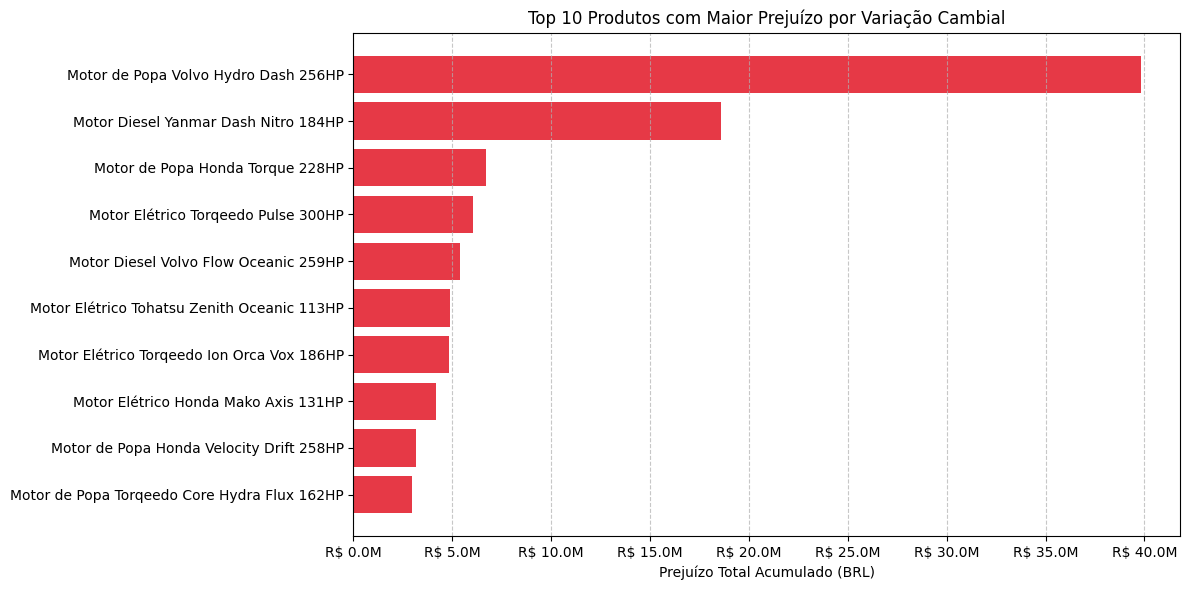

In [26]:
# Filtrar apenas quem teve prejuízo e ordenar pelos maiores prejuízos absolutos
df_grafico = agg_produtos[agg_produtos["prejuizo_total"] < 0].copy()
df_grafico = df_grafico.sort_values("prejuizo_total", ascending=True).head(10) # Top 10 prejuízos
df_grafico["prejuizo_total_abs"] = df_grafico["prejuizo_total"].abs()

plt.figure(figsize=(12, 6))
bars = plt.barh(df_grafico["product_name"], df_grafico["prejuizo_total_abs"], color='#e63946')

# Formatação do Eixo X para Reais (Milhões)
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M'))
plt.xlabel("Prejuízo Total Acumulado (BRL)")
plt.title("Top 10 Produtos com Maior Prejuízo por Variação Cambial")
plt.gca().invert_yaxis() # Maior prejuízo no topo
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('grafico_prejuizo_produtos.png')
plt.show()

> Parte 3 - Análise Objetiva

In [28]:
# 1. Localizando o maior prejuízo absoluto
# idxmin() encontra o índice do menor valor (mais negativo)
maior_prejuizo_abs = agg_produtos.loc[agg_produtos["prejuizo_total"].idxmin()]

# 2. Localizando a maior porcentagem de perda
maior_porcentagem_perda = agg_produtos.loc[agg_produtos["pct_perda"].idxmax()]

# 3. Verificação para a pergunta 2 (Ajustado para 'id_product')
mesmo_produto = maior_prejuizo_abs['id_product'] == maior_porcentagem_perda['id_product']

print(f"1. Qual produto concentra o maior prejuízo absoluto?")
print(f"R: {maior_prejuizo_abs['product_name']} com um prejuízo de R$ {maior_prejuizo_abs['prejuizo_total']:,.2f}")

print(f"\n2. O produto com maior prejuízo absoluto também é o que possui a maior porcentagem de perda?")
if mesmo_produto:
    print(f"R: Sim. O produto {maior_prejuizo_abs['product_name']} lidera em ambas as métricas ({maior_porcentagem_perda['pct_perda']}% de perda).")
else:
    print(f"R: Não. O produto com maior % de perda é {maior_porcentagem_perda['product_name']} ({maior_porcentagem_perda['pct_perda']}%).")

1. Qual produto concentra o maior prejuízo absoluto?
R: Motor de Popa Volvo Hydro Dash 256HP com um prejuízo de R$ -39,809,090.51

2. O produto com maior prejuízo absoluto também é o que possui a maior porcentagem de perda?
R: Sim. O produto Motor de Popa Volvo Hydro Dash 256HP lidera em ambas as métricas (63.13% de perda).
